In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install pulp
import pulp

In [ ]:
# Iterative MILP Solver (Cutting Plane Method)
def solve_miqp_via_milp(r, Q, lambda_val, m, M, fmin, fmax, max_iters=10):
    N = len(r)
    prob = pulp.LpProblem("Portfolio_Optimization", pulp.LpMaximize)

    # Variables
    x = [pulp.LpVariable(f'x_{i}', lowBound=0, upBound=1) for i in range(N)]
    v = [pulp.LpVariable(f'v_{i}', cat='Binary') for i in range(N)]
    z = pulp.LpVariable('z', lowBound=0) # Slack for quadratic term

    # Objective: maximize (r^T * x - lambda * z)
    prob += pulp.lpSum([r[i] * x[i] for i in range(N)]) - lambda_val * z

    # Constraints
    prob += pulp.lpSum(x) == 1  # Full investment
    prob += pulp.lpSum(v) <= M  # Max assets
    prob += pulp.lpSum(v) >= m  # Min assets

    for i in range(N):
        prob += x[i] <= fmax * v[i]
        prob += x[i] >= fmin * v[i]

    history = []
    current_x_vals = np.ones(N) / N # Initial guess

    for i in range(max_iters):
        # Add cutting plane constraint: -x0'Qx0 + 2x0'Qx - z <= 0
        # Which is: 2 * (x0'Q) * x - z <= x0'Qx0
        Q_x0 = current_x_vals.T @ Q
        x0_Q_x0 = current_x_vals.T @ Q @ current_x_vals

        prob += 2 * pulp.lpSum([Q_x0[j] * x[j] for j in range(N)]) - z <= x0_Q_x0

        # Solve
        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        # Extract results
        new_x = np.array([pulp.value(x_var) for x_var in x])
        z_val = pulp.value(z)
        true_quadratic = new_x.T @ Q @ new_x

        history.append((true_quadratic, z_val))

        # Update x (using the 'midway' heuristic from the MATLAB code)
        current_x_vals = (current_x_vals + new_x) / 2

        if abs(z_val - true_quadratic) / max(1e-6, true_quadratic) < 1e-4:
            break

    return new_x, history

final_assets, history = solve_miqp_via_milp(r, Q, lambda_val, m, M, fmin, fmax)
print("Optimization Complete.")

Optimization Complete.


## Real-data instance

Data is loaded from the frozen 50-stock MIQP universe at `data/prices/prices_miqp_daily.csv` (1255 trading days, 2021-01-04 to 2025-12-31, no missing values). This replaces the original `yfinance` fetch so every teammate runs on the **same data** — results are directly comparable.

To regenerate the CSV from yfinance, run `scripts/fetch_prices.py --universe miqp`.

In [ ]:
# Load the frozen MIQP price history (50 stocks)
import sys
from pathlib import Path

# Make benchmark_protocol importable when running from the notebook's folder
sys.path.insert(0, str(Path.cwd()))
from benchmark_protocol import prices

# Frozen analysis window: most recent complete year.
# Change here only if you also document it in your BenchmarkResult hyperparameters.
START = "2025-01-01"
END   = "2025-12-31"

returns_df = prices.load_returns(start=START, end=END, universe="miqp")
tickers_clean = returns_df.columns.tolist()

# Expected returns (mean daily return) and covariance — same convention as the original notebook
r_real = returns_df.mean().values
Q_real = returns_df.cov().values

N_real = len(tickers_clean)
print(f"Loaded {N_real} stocks, {len(returns_df)} trading days "
      f"({returns_df.index.min().date()} -> {returns_df.index.max().date()})")


Optimal Portfolio Allocation:


,0
JNJ,0.250000
CVX,0.164923
WMT,0.142284
GOOGL,0.132795
VZ,0.112633
NVDA,0.077173
BAC,0.062027
RTX,0.038166
MSFT,0.020000


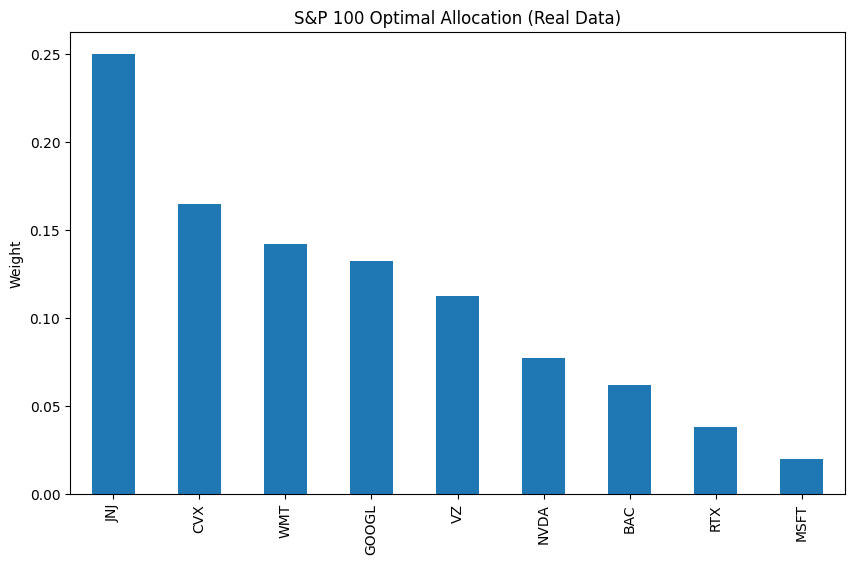

In [ ]:
# Run Optimization on Real Data
# Adjust constraints for the actual number of assets returned
m_real = 5   # Min assets in portfolio
M_real = 15  # Max assets in portfolio
fmin_real = 0.02 # minimum weight of single asset
fmax_real = 0.25 # maximum weight of single asset
lambda_real = 50 #A higher lambda makes the solver more 'scared' of risk,
#leading it to prefer stable stocks, while a lower lambda would make it chase higher
# returns even if the portfolio is more volatile

final_assets_real, history_real = solve_miqp_via_milp(
    r_real, Q_real, lambda_real, m_real, M_real, fmin_real, fmax_real, max_iters=15
)

# Display Results
portfolio_results = pd.Series(final_assets_real, index=tickers_clean)
portfolio_results = portfolio_results[portfolio_results > 0].sort_values(ascending=False)

print("\nOptimal Portfolio Allocation:")
display(portfolio_results)

plt.figure(figsize=(10, 6))
portfolio_results.plot(kind='bar')
plt.title('S&P 100 Optimal Allocation (Real Data)')
plt.ylabel('Weight')
plt.show()

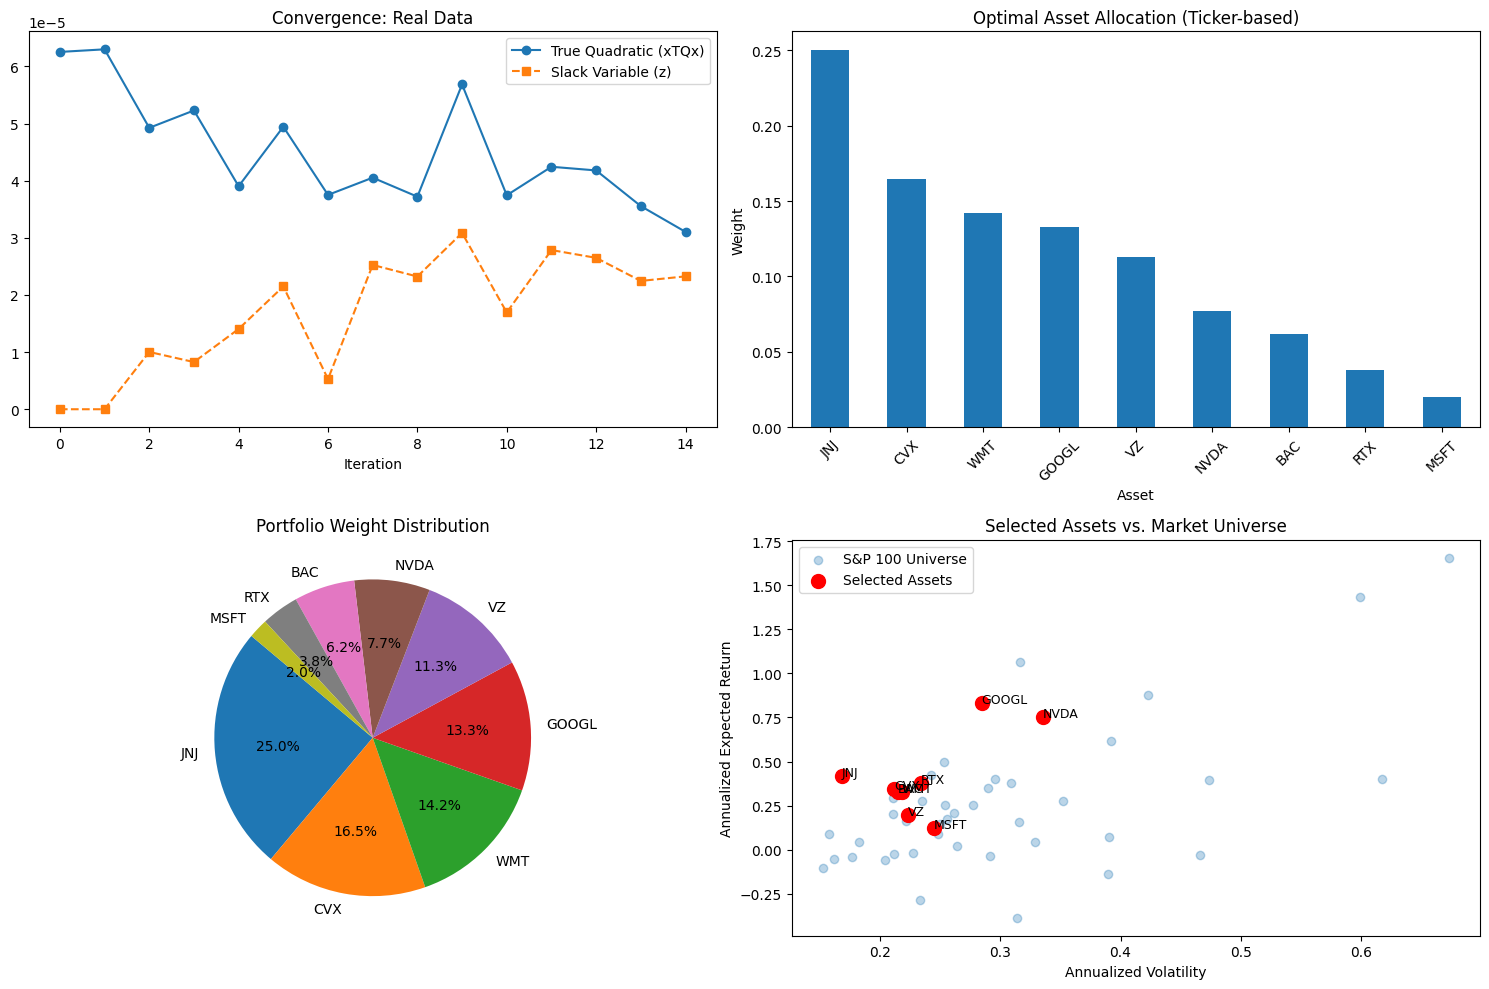

In [ ]:
# More Visualization?
history_real_np = np.array(history_real)
plt.figure(figsize=(15, 10))

# Subplot 1: Convergence (Matching original format)
plt.subplot(2, 2, 1)
plt.plot(history_real_np[:, 0], 'o-', label='True Quadratic (xTQx)')
plt.plot(history_real_np[:, 1], 's--', label='Slack Variable (z)')
plt.title('Convergence: Real Data')
plt.xlabel('Iteration')
plt.legend()

# Subplot 2: Asset Allocation Bar
plt.subplot(2, 2, 2)
# Using the series we created earlier which filtered for values > 0
portfolio_results.plot(kind='bar')
plt.title('Optimal Asset Allocation (Ticker-based)')
plt.ylabel('Weight')
plt.xlabel('Asset')
plt.xticks(rotation=45)

# Subplot 3: Portfolio Composition Pie Chart
plt.subplot(2, 2, 3)
portfolio_results.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Portfolio Weight Distribution')
plt.ylabel('')

# Subplot 4: Risk-Return Scatter
plt.subplot(2, 2, 4)
volatility = returns_df.std() * np.sqrt(252)
annual_returns = returns_df.mean() * 252

plt.scatter(volatility, annual_returns, alpha=0.3, label='S&P 100 Universe')
selected_tickers = portfolio_results.index
plt.scatter(volatility[selected_tickers], annual_returns[selected_tickers], color='red', s=100, label='Selected Assets')

for t in selected_tickers:
    plt.annotate(t, (volatility[t], annual_returns[t]), fontsize=9)

plt.title('Selected Assets vs. Market Universe')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Expected Return')
plt.legend()

plt.tight_layout()
plt.show()